## Reviewer Response Figures:


In [27]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)

#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder, plot_heatmap_w_kwargs
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels, set_stage_xticks_2_layer
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.8.4 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


### Non-supplement

#### Autoencoder hidden layer/activation function comparison

In [28]:
sweep_df_filename = r"_content_NN_param_sweep_02_Feb_2026_annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet"
sweep_results_df = pd.read_parquet(data_location / Path(sweep_df_filename))

In [29]:
sweep_results_df

,db_index,final_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison,n_frames_to_draw,n_epochs,n_bootstrap,BATCH_SIZE,axis
0,1.426356,0.068241,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
1,1.482833,0.069200,relu,2,1,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
2,1.025204,0.070144,relu,2,2,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
3,0.784805,0.064127,relu,2,3,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
4,1.260454,0.066928,relu,2,4,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,2.643163,0.044813,mish,5,995,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23996,1.730298,0.042891,mish,5,996,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23997,1.963058,0.042783,mish,5,997,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23998,2.409398,0.042226,mish,5,998,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0


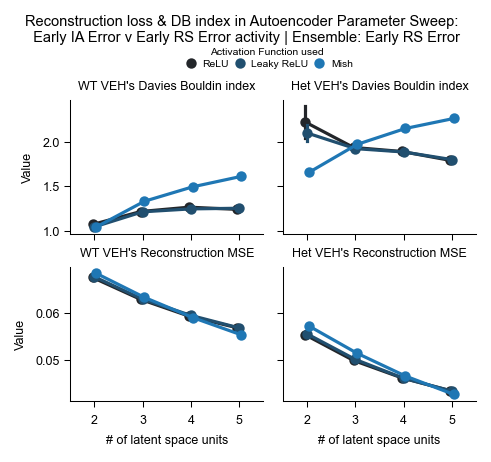

In [30]:
# Faceted pointplot: one panel per genotype
# set var names
comparison = sweep_results_df['comparison'].iloc[0]
ensemble = sweep_results_df['ensemble'].iloc[0]
# make plot
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['db_index', 'final_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'db_index': 'Davies Bouldin index', 'final_loss': 'Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s {row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 0.99, 
                  fontsize=7)
plt.savefig(f"sweep_results_{ensemble}.png", dpi=150, bbox_inches='tight')

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\27_Feb_2026' has been created.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\27_Feb_2026' has been created.


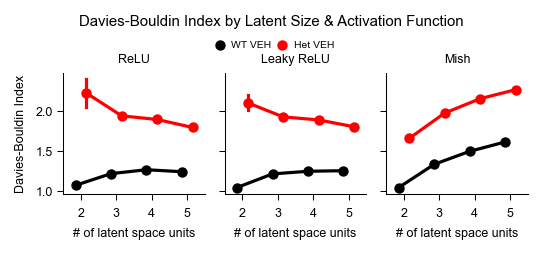

In [31]:
# FacetGrid: DB index by # latent units, faceted by activation function, dodged by genotype
# Build a palette dict from geno_color_dict mapping: WT VEH -> black, Het VEH -> red
geno_palette = {g: c for g, c in zip(geno_color_dict['hue_order'], geno_color_dict['palette'])}
# Filter to only WT VEH and Het VEH
db_df = sweep_results_df[sweep_results_df['geno'].isin(['WT VEH', 'Het VEH'])].copy()
db_df['geno'] = pd.Categorical(db_df['geno'], categories=['WT VEH', 'Het VEH'], ordered=True)

label_rename_act = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
db_df['activation_label'] = db_df['activation'].map(label_rename_act)

g = sns.FacetGrid(db_df, col='activation_label', height=1.5, aspect=0.8,sharey=True, sharex=True,
                  col_order=[label_rename_act[a] for a in ['relu', 'leaky_relu', 'mish']])
g.map_dataframe(sns.pointplot, x='hidden_size', y='db_index',
                hue='geno', palette=geno_palette, hue_order=['WT VEH', 'Het VEH'],
                dodge=0.3, errorbar='se')

g.set_titles("{col_name}")
g.set_axis_labels("# of latent space units", "Davies-Bouldin Index")
g.figure.subplots_adjust(top=0.8)

handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.975), ncol=2, frameon=False)
g.figure.suptitle("Davies-Bouldin Index by Latent Size & Activation Function", y=1.06)
save_fig_in_main_fig_dir(g.figure,fig_name = "Davies-Bouldin Index by Latent Size_Activation Function", folder_key='s_2', filetypes_to_save = ['png','svg'])


#### Compare DFF vs Spikes ensemble values

#### import dff & spike datasets

In [32]:
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'


In [33]:
#load spike data:


trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
print(n_total_units)

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64


In [34]:
enriched_spikes = unit_mean_tseries.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_spikes

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-104 Het VEH                      0             0.0   
             10_3_HET_RS1-107 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-104 Het VEH                      0               1   
             10_3_HET_RS1-107 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-104 Het VEH             1        0  
             10_3_HET_RS1-107 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[4776 rows x 6 columns]

In [35]:
# load DFF data
dff_file = data_location / Path(r"matlab_import_1000_shuff_minmax_normed_trial_tseries_26-Feb-2026\dff_matlab-made_trial_timeseries_normalized_2026-02-26 21.parquet")
trial_tseries_df_norm_dff = pd.read_parquet(dff_file)
n_total_units_dff = trial_tseries_df_norm_dff.groupby(by = 'geno_day')[unit_ID_col].nunique()
#make dff mean timeseries
unit_mean_tseries_dff =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm_dff,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)

print(n_total_units_dff)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1350
Name: neuron_ID, dtype: int64


In [36]:
enriched_dff = unit_mean_tseries_dff.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_dff

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-100 Het VEH                      0             0.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-102 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               1   
             10_3_HET_RS1-100 Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-102 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-100 Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-102 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[5961 rows x 6 columns]

#### Reviewer figure: Heatmap of dff

In [37]:
##Define functions to use for activity matrix creation
def get_df_unit_mean_activity_matrix(unit_mean_tseries, 
                                     stage_names,
                                     numeric_col, 
                                     subj_name_col:str = 'subject_name', 
                                     ignore_pre:bool = True):
    all_geno_matrix,  all_geno_IDs= get_unit_mean_phase_activity_matrix( unit_mean_tseries, 
                                                                        use_enrich_unit_only=  False,
                                                                          stage_names =  stage_names,
                                                                          numeric_col =  numeric_col,
                                                                           subj_name_col = subj_name_col,
                                                                            unit_ID_col = unit_ID_col,
                                                                             ignore_pre= ignore_pre)
    mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(
        unit_mean_tseries.groupby(unit_ID_col)['geno_day'].first().to_frame(),left_index = True, right_index = True)
    if np.nanmean(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) == 0)>0:
        mean_AV_matrix = mean_AV_matrix.loc[(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) > 0),:]
    return mean_AV_matrix

## preprocessing and normalization steps
def get_unit_mean_phase_activity_matrix(unit_mean_tseries, 
                                        use_enrich_unit_only,
                                          stage_names,
                                            numeric_col,
                                            subj_name_col = 'subject_name',
                                             unit_ID_col = 'neuron_ID',
                                              ignore_pre:bool= True, ):
    '''#TO- create matrix that's = concatenated vectors of all neuron mean activationni phase (output matrix = # units x # phases)    OUTPUT- '''
    matrix_IDs, stack_matrix,nan_df_list = dict(), dict(),[]
    skip_rec = dict()
    ## if going to skip pre-outcome period, change what counts as numeric col
    if ignore_pre:
        numeric_col = [col for col in numeric_col if '-' not in col]
    for dataset in unit_mean_tseries[subj_name_col].unique():
        matrix_list = []
        dataset_df = unit_mean_tseries.loc[ (unit_mean_tseries[subj_name_col] == dataset),:]
        if len(dataset_df.task_phase_vec.unique()) < len(stage_names):#check that dataset has ALL 6 phases, if not, skip
            skip_rec[dataset] = len(dataset_df.task_phase_vec.unique())
            # continue
        for stage in stage_names:
            phase_mask = (dataset_df.task_phase_vec == stage)
            matrix = dataset_df.loc[phase_mask, numeric_col].values #get phase entries, producing (dataset_neuron) x (time_bin matrix)
            #check if phase is present, if matrix extracted w phase trials is empty, assume mous elacks it
            if matrix.shape[0] == 0:
                matrix = np.tile(np.nan, (len(dataset_df[unit_ID_col].unique()), len(numeric_col)))
            if np.sum(np.isnan(matrix))>0:
                nan_df_list.append( dataset_df.loc[phase_mask, numeric_col])
            matrix_list.append(matrix)
        stack_matrix[dataset] = np.dstack(matrix_list)
        matrix_IDs[dataset] = dataset_df.loc[phase_mask, unit_ID_col].values
    all_geno_matrix = np.concatenate([val for val in stack_matrix.values()], axis = 0)
    all_geno_IDs =  np.concatenate([val for val in matrix_IDs .values()], axis = 0)
    return all_geno_matrix, all_geno_IDs

## extract tseries of interest to create AV matrix
ID_col_to_drop = 'cell' 
AV_matrix = get_df_unit_mean_activity_matrix(unit_mean_tseries_dff, stage_names, numeric_col,subj_name_col = 'subject_name', ignore_pre =True) # other way will not work: # AV_matrix =  get_df_unit_mean_activity_matrix(trial_tseries_df, stage_names, numeric_col)
AV_matrix['max_phase'] =AV_matrix[stage_names].idxmax(axis = 'columns')
max_95th_quantile = round(AV_matrix[stage_names].quantile(q = 0.95).max(),2)
min_5th_quantile = round(AV_matrix[stage_names].quantile(q = 0.05).min(),2)
print(f"5th percentile mean activation: {min_5th_quantile}, 95th percentile: {max_95th_quantile}")
WT_mask = AV_matrix.geno_day == "WT VEH"
AV_matrix['max_phase_val'] =AV_matrix.apply(lambda x: x[x.max_phase], axis = 1)
no_Early_IA_Error = AV_matrix.Early_IA_Error.isna()
has_Early_IA_Error = ~no_Early_IA_Error
AV_matrix.tail()

5th percentile mean activation: -0.44, 95th percentile: 1.77


C:\Users\13car\AppData\Local\Temp\ipykernel_25796\84984833.py:14: RuntimeWarning: Mean of empty slice
  mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(


,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,geno_day,max_phase,max_phase_val
9_3_HET_RS3-95,-0.333195,0.087563,-0.146866,-0.292228,0.049979,0.127020,Het postCLNZ,Late_RS,0.127020
9_3_HET_RS3-96,-0.272123,0.898245,0.664034,-0.285116,-0.272407,-0.231106,Het postCLNZ,Early_IA_Error,0.898245
9_3_HET_RS3-97,0.413765,3.780134,-0.268930,0.037388,-0.067772,0.014236,Het postCLNZ,Early_IA_Error,3.780134
9_3_HET_RS3-98,-0.143967,-0.113177,-0.181281,-0.214394,-0.199272,-0.196949,Het postCLNZ,Early_IA_Error,-0.113177
9_3_HET_RS3-99,-0.276386,-0.363606,-0.264345,0.040973,0.009452,-0.179825,Het postCLNZ,Early_RS_Error,0.040973


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\27_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\27_Feb_2026' already exists.


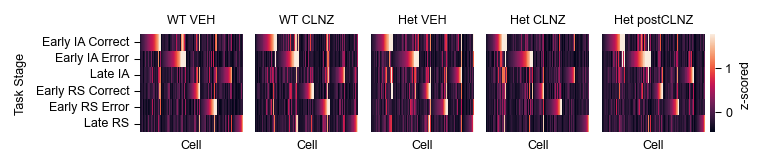

In [38]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,5,figsize = (5,1), layout = 'constrained')
activity_type =  f"z-scored "
heatmap_clabel = activity_type

for count, geno in enumerate(geno_order_w_WT_CLNZ):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = {
                              'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order_w_WT_CLNZ)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})#plot heatmap
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_prefix = "supp_" #for sorting in folder
fig_name = 'one_row_cell stage-activity sorted heatmap'
fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['png'])

#### Reviewer figure- compute ensemble size/distribution

In [77]:
unique_ID_enrichment_dff = unit_mean_tseries_dff.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment_dff.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'% enriched')
geno_mean_enrich.head()

,geno_day,phase,% enriched
0,Het CLNZ,Early_IA_Correct,0.118830
1,Het VEH,Early_IA_Correct,0.164534
2,Het postCLNZ,Early_IA_Correct,0.139337
3,WT CLNZ,Early_IA_Correct,0.117978
4,WT VEH,Early_IA_Correct,0.112593


In [85]:
prop_of_cells_enrich_n_stages = unique_ID_enrichment_dff.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=True).rename('prop_enrich').reset_index()
prop_of_cells_enrich_n_stages.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.690128
1,Het CLNZ,1.0,0.192870
2,Het CLNZ,2.0,0.065814
3,Het CLNZ,3.0,0.035649
4,Het CLNZ,4.0,0.011883


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\supp_fig_2\27_Feb_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\27_Feb_2026' already exists.


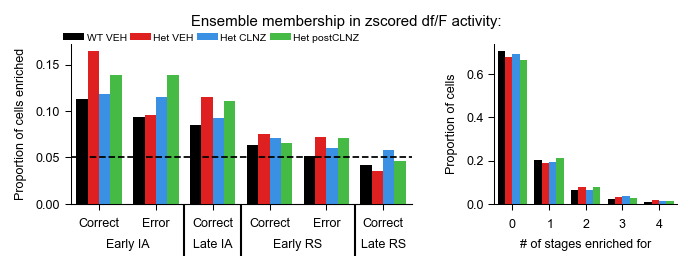

In [86]:
fig, axes = plt.subplots(1,2, figsize = (4.5,1.5), layout = 'constrained', width_ratios = [0.65, 0.35], gridspec_kw = dict(wspace = 0.1))

## plot distib of # enriched units by phase
ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich, x = 'phase', y = '% enriched',
                order = phase_list_IA_RS_chrono, **geno_color_dict)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion of cells enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages, x = 'num_enrich',  y = 'prop_enrich',  **geno_color_dict_no_errorbar) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))

#set figure legends and info 
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.3, 0.95),loc = 'lower center', ncols =4, frameon = False, title =None, **legend_defaults)
fig.suptitle(f"Ensemble membership in zscored df/F activity:", y = 1.1)
#####save fig
fig_name =  r"SUPP_ dff # enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_2', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

#### check overlap of consistent ids

In [42]:
unit_mean_tseries

,subject_name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,max_val,max_val_tbin,mean_rate
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,0.0,0.0,0.0,0.0,0.0,0.8,...,1.0,True,none,1.0,all_frames,0.6025,True,1.0,-1.5s to -1.25s,0.690000
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_IA_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27764,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27765,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,none,1.0,all_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27766,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,False,none,1.0,all_frames,0.0350,True,0.2,4.0s to 4.25s,0.009333


In [43]:
merged_enriched_chunks = pd.merge(enriched_spikes,enriched_dff, how = 'inner', on=['subject_name', 'geno_day', unit_ID_col], suffixes=('_dff', '_spikes'))
merged_enriched_chunks

Early_IA_Correct_dff  \
subject_name geno_day     neuron_ID                                
10_3_HET_RS1 Het VEH      10_3_HET_RS1-1                       0   
                          10_3_HET_RS1-10                      0   
                          10_3_HET_RS1-101                     0   
                          10_3_HET_RS1-104                     0   
                          10_3_HET_RS1-107                     0   
...                                                          ...   
9_3_HET_RS3  Het postCLNZ 9_3_HET_RS3-95                       0   
                          9_3_HET_RS3-96                       0   
                          9_3_HET_RS3-97                       0   
                          9_3_HET_RS3-98                       0   
                          9_3_HET_RS3-99                       0   

                                            Early_IA_Error_dff  \
subject_name geno_day     neuron_ID                              
10_3_HET_RS1 Het VEH      10_3_HET_RS1-1                   1.0   
                          10_3_HET_RS1-10                  1.0   
                          10_3_HET_RS1-101                 0.0   
                          10_3_HET_RS1-104                 0.0   
                          10_3_HET_RS1-107                 0.0   
...                                                        ...   
9_3_HET_RS3  Het postCLNZ 9_3_HET_RS3-95                   0.0   
                          9_3_HET_RS3-96                   0.0   
                          9_3_HET_RS3-97                   1.0   
                          9_3_HET_RS3-98                   0.0   
                          9_3_HET_RS3-99                   0.0   

                                            Early_RS_Correct_dff  \
subject_name geno_day     neuron_ID                                
10_3_HET_RS1 Het VEH      10_3_HET_RS1-1                       0   
                          10_3_HET_RS1-10                      0   
                          10_3_HET_RS1-101                     0   
                          10_3_HET_RS1-104                     0   
                          10_3_HET_RS1-107                     0   
...                                                          ...   
9_3_HET_RS3  Het postCLNZ 9_3_HET_RS3-95                       0   
                          9_3_HET_RS3-96                       0   
                          9_3_HET_RS3-97                       0   
                          9_3_HET_RS3-98                       0   
                          9_3_HET_RS3-99                       0   

                                            Early_RS_Error_dff  Late_IA_dff  \
subject_name geno_day     neuron_ID                                           
10_3_HET_RS1 Het VEH      10_3_HET_RS1-1                     0            0   
                          10_3_HET_RS1-10                    0            0   
                          10_3_HET_RS1-101                   0            0   
                          10_3_HET_RS1-104                   1            1   
                          10_3_HET_RS1-107                   0            0   
...                                                        ...          ...   
9_3_HET_RS3  Het postCLNZ 9_3_HET_RS3-95                     0            0   
                          9_3_HET_RS3-96                     0            0   
                          9_3_HET_RS3-97                     0            0   
                          9_3_HET_RS3-98                     0            0   
                          9_3_HET_RS3-99                     0            0   

                                            Late_RS_dff  \
subject_name geno_day     neuron_ID                       
10_3_HET_RS1 Het VEH      10_3_HET_RS1-1              0   
                          10_3_HET_RS1-10             0   
                          10_3_HET_RS1-101            0   
                          10_3_HET_RS1-104            0   
                          10_3_HE

In [44]:
# Cross-tabulation of dff vs spikes enrichment, faceted by geno_day
dff_cols = [c for c in merged_enriched_chunks.columns if c.endswith('_dff')]
base_stages = [c.replace('_dff', '') for c in dff_cols]

summary_rows = []
for stage in base_stages:
    dff_col = f"{stage}_dff"
    spike_col = f"{stage}_spikes"
    pair = merged_enriched_chunks[[dff_col, spike_col]].dropna()
    pair = pair.assign(**{dff_col: pair[dff_col].astype(int), spike_col: pair[spike_col].astype(int)})

    for geno_day, grp in pair.groupby(level='geno_day'):
        n = len(grp)
        both_0    = ((grp[dff_col] == 0) & (grp[spike_col] == 0)).sum()
        dff_only  = ((grp[dff_col] == 1) & (grp[spike_col] == 0)).sum()
        spike_only = ((grp[dff_col] == 0) & (grp[spike_col] == 1)).sum()
        both_1    = ((grp[dff_col] == 1) & (grp[spike_col] == 1)).sum()
        summary_rows.append({
            'stage': stage,
            'geno_day': geno_day,
            'n': n,
            'neither': both_0,
            'dff_only': dff_only,
            'spikes_only': spike_only,
            'both': both_1,
        })

crosstab_summary = pd.DataFrame(summary_rows)
# Add percentage columns
for col in ['neither', 'dff_only', 'spikes_only', 'both']:
    crosstab_summary[f'{col}_pct'] = (crosstab_summary[col] / crosstab_summary['n'] * 100).round(1)

display(crosstab_summary)


,stage,geno_day,n,neither,dff_only,spikes_only,both,neither_pct,dff_only_pct,spikes_only_pct,both_pct
0,Early_IA_Correct,Het CLNZ,866,711,27,46,82,82.1,3.1,5.3,9.5
1,Early_IA_Correct,Het VEH,874,673,28,56,117,77.0,3.2,6.4,13.4
2,Early_IA_Correct,Het postCLNZ,937,737,39,59,102,78.7,4.2,6.3,10.9
3,Early_IA_Correct,WT CLNZ,1019,848,30,51,90,83.2,2.9,5.0,8.8
4,Early_IA_Correct,WT VEH,1080,898,38,73,71,83.1,3.5,6.8,6.6
5,Early_IA_Error,Het CLNZ,742,608,28,37,69,81.9,3.8,5.0,9.3
6,Early_IA_Error,Het VEH,749,636,24,26,63,84.9,3.2,3.5,8.4
7,Early_IA_Error,Het postCLNZ,689,540,31,29,89,78.4,4.5,4.2,12.9
8,Early_IA_Error,WT CLNZ,838,720,23,35,60,85.9,2.7,4.2,7.2
9,Early_IA_Error,WT VEH,870,751,25,33,61,86.3,2.9,3.8,7.0
